In [25]:
raw_results_humanbaseline_Nov23 = [
    "raw_results_humanbaseline_Nov23/kanha_episode_scores.json",
    "raw_results_humanbaseline_Nov23/aadi_episode_scores.json",
    "raw_results_humanbaseline_Nov23/rakshit_episode_scores.json",
    "raw_results_humanbaseline_Nov23/vaishnavi_episode_scores.json",
    "raw_results_humanbaseline_Nov23/samhitha_episode_scores.json",
]


mean length of all episodes:  16.0


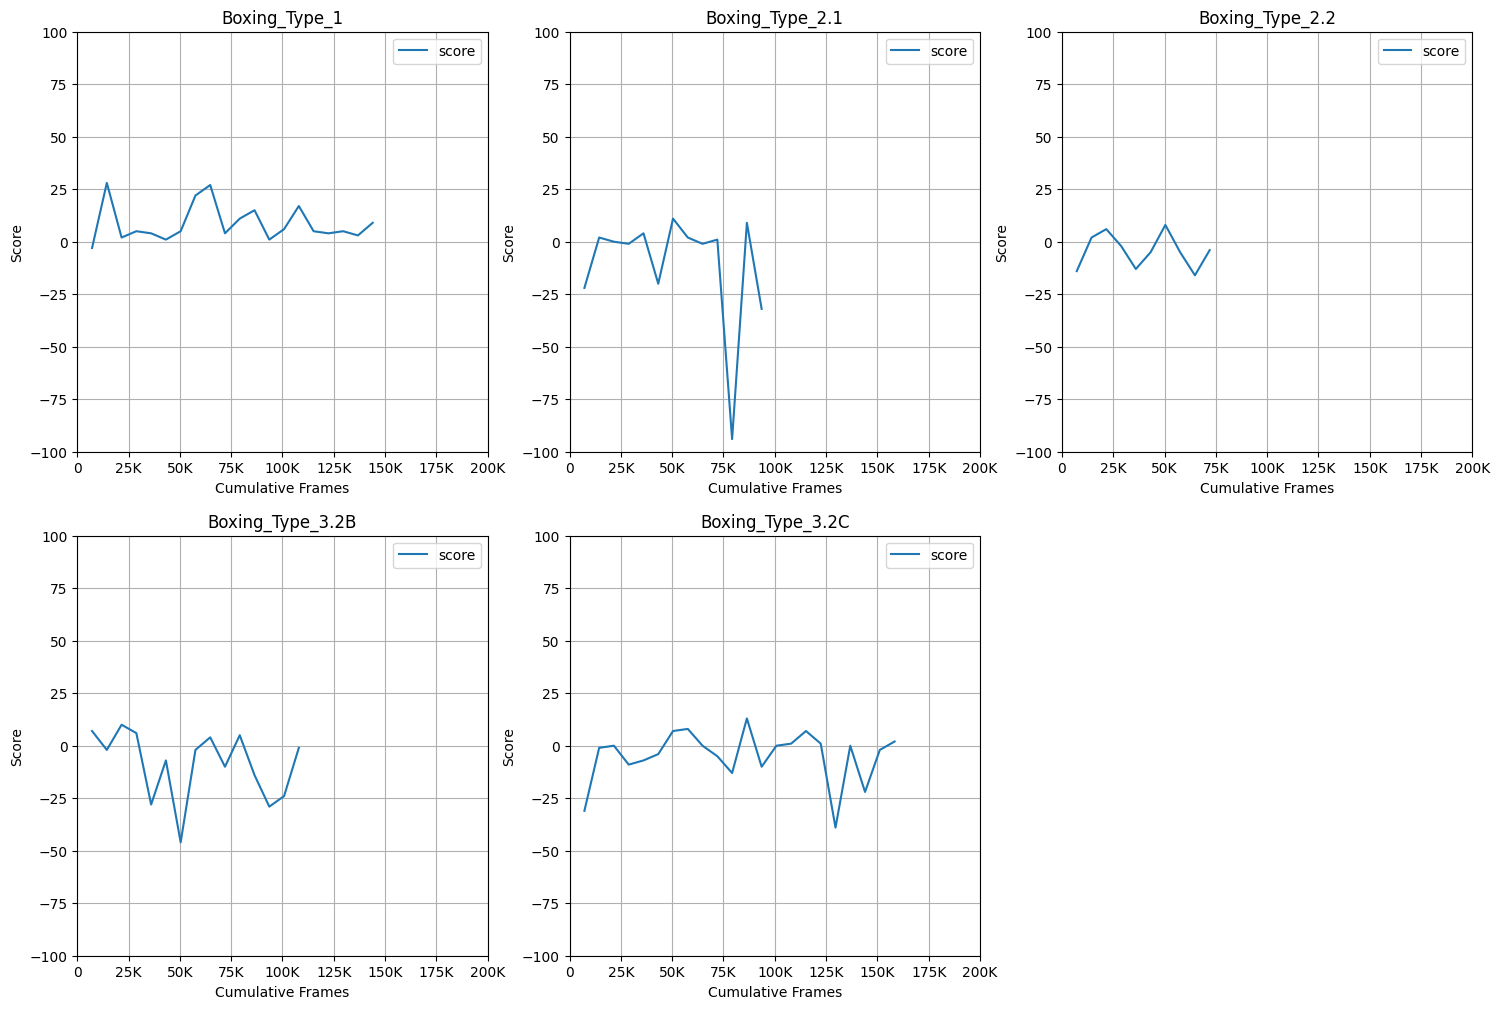

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import math

def format_k_notation(x, pos):
    """Format numbers with K notation (e.g., 1000 -> 1K)"""
    if x >= 1000:
        return f'{x/1000:.0f}K'
    return f'{x:.0f}'

n_files = len(raw_results_humanbaseline_Nov23)
n_cols = math.ceil(math.sqrt(n_files))
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(6*n_cols, 6*n_rows))
axes = axes.flatten()

all_lengths = []
for i in range(n_files):
    df = pd.read_json(raw_results_humanbaseline_Nov23[i], orient="index")
    all_lengths.append(len(df))
    df.columns = ['score']  # Name the column
    # df.index.name = 'episode'
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'episode'}, inplace=True)
    df['timestamp'] = df['episode'].str.split('_').str[-1]
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Calculate time difference from previous row
    df['delta_time'] = df['timestamp'].diff()
    df['frames_per_episode'] = pd.Series([7200]*len(df), index=df.index)
    df['cumulative_frames'] = df['frames_per_episode'].cumsum()
    df
    df.plot(x='cumulative_frames', y='score', kind='line', ax=axes[i])
    axes[i].set_xlabel('Cumulative Frames')
    axes[i].set_ylabel('Score')
     # Set fixed axis limits
    axes[i].set_xlim(0, 200000)
    axes[i].set_ylim(-100, 100)
    axes[i].grid(True)
    # Apply K notation formatter to y-axis
    axes[i].xaxis.set_major_formatter(FuncFormatter(format_k_notation))
    type_key = df['episode'].str.split('_').str[0:3].str.join('_')[0]
    axes[i].set_title(f'{type_key}')

axes[i+1].set_visible(False)

print("mean length of all episodes: ", sum(all_lengths) / len(all_lengths))